# Integrated power-flux parameter sweep

Read every power_flux_timeseries_{maximum_wind_m_s}_{radius_km}.csv file, integrate the outward power flux from 0 to time_max, and plot the result on the maximum-wind/radius parameter plane.

In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np

# This works when Jupyter starts in either the repository root or plots/.
cwd = Path.cwd().resolve()
repo_root = next(
    (path for path in (cwd, *cwd.parents) if (path / "src" / "config.yaml").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

output_dir = repo_root / "outputs"
print(f"Reading model output from {output_dir}")

Reading model output from /geode3/home/u020/ckieu/BigRed200/model/vortex-waves/outputs


In [2]:
def get_flux_grid(files,time_max_s,prefix):
    number = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
    filename_pattern = re.compile(
        rf"^{prefix}_(?P<wind>{number})_(?P<radius>{number})\.csv$"
    )
    
    integrated_flux = {}
    for power_path in files:
        match = filename_pattern.fullmatch(power_path.name)
        if match is None:
            continue
    
        maximum_wind_m_s = float(match.group("wind"))
        radius_km = float(match.group("radius"))
        key = (maximum_wind_m_s, radius_km)
        if key in integrated_flux:
            raise ValueError(f"Duplicate parameter pair {key} in {power_path.name}")
    
        data = np.atleast_1d(np.genfromtxt(power_path, delimiter=",", names=True))
        column_names = set(data.dtype.names or ())
        missing_columns = {"time_s", "power_W"} - column_names
        if missing_columns:
            raise ValueError(f"{power_path.name} is missing columns {sorted(missing_columns)}")
    
        time_s = np.asarray(data["time_s"], dtype=float)
        power_w = np.asarray(data["power_W"], dtype=float)
        if time_s.size < 2 or not np.all(np.isfinite(time_s)) or not np.all(np.isfinite(power_w)):
            raise ValueError(f"{power_path.name} must contain at least two finite samples")
    
        order = np.argsort(time_s)
        time_s = time_s[order]
        power_w = power_w[order]
        if np.any(np.diff(time_s) <= 0.0):
            raise ValueError(f"{power_path.name} has duplicate or non-increasing times")
        if time_s[0] > 0.0 or time_s[-1] < time_max_s:
            raise ValueError(
                f"{power_path.name} covers {time_s[0] / 3600:g} to "
                f"{time_s[-1] / 3600:g} h, not the requested 0 to {time_max:g} h"
            )
    
        # Add interpolated endpoints so the integral ends exactly at time_max.
        interior = (time_s > 0.0) & (time_s < time_max_s)
        integration_time_s = np.concatenate(([0.0], time_s[interior], [time_max_s]))
        integration_power_w = np.interp(integration_time_s, time_s, power_w)
        integrated_flux[key] = float(np.trapezoid(integration_power_w, integration_time_s))
    
    if not integrated_flux:
        raise FileNotFoundError(
            f"No files matching power_flux_timeseries_<wind>_<radius>.csv found in {output_dir}"
        )
    
    wind_values = np.array(sorted({wind for wind, _ in integrated_flux}))
    radius_values = np.array(sorted({radius for _, radius in integrated_flux}))
    flux_grid = np.full((radius_values.size, wind_values.size), np.nan)
    wind_index = {value: index for index, value in enumerate(wind_values)}
    radius_index = {value: index for index, value in enumerate(radius_values)}
    for (wind, radius), flux in integrated_flux.items():
        flux_grid[radius_index[radius], wind_index[wind]] = flux
    
    missing_pairs = int(np.isnan(flux_grid).sum())
    if missing_pairs:
        print(f"Warning: {missing_pairs} wind/radius combinations are missing and will be blank.")
    print(
        f"Integrated {len(integrated_flux)} files from 0 to {time_max:g} h; "
        f"grid shape = {flux_grid.shape}."
    )
    
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    mesh = ax.pcolormesh(
        wind_values,
        radius_values,
        np.ma.masked_invalid(flux_grid),
        shading="nearest",
        cmap="viridis",
    )
    ax.scatter(*np.meshgrid(wind_values, radius_values), s=15, color="white", alpha=0.65)
    ax.set(
        xlabel="Maximum wind speed (m s$^{-1}$)",
        ylabel="Radius (km)",
        title=f"Integrated outward power flux, 0–{time_max:g} h",
        xticks=wind_values,
        yticks=radius_values,
    )
    colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    colorbar.set_label("Time-integrated outward power flux (J)")
    colorbar.formatter.set_powerlimits((0, 0))
    colorbar.update_ticks()
    fig.tight_layout()
    plt.show()    

    return integrated_flux

## 1. Plot at far-field location R_out = 900 km, using TC-following perturbation ring fully coupled

Integrated 32 files from 0 to 2 h; grid shape = (8, 4).


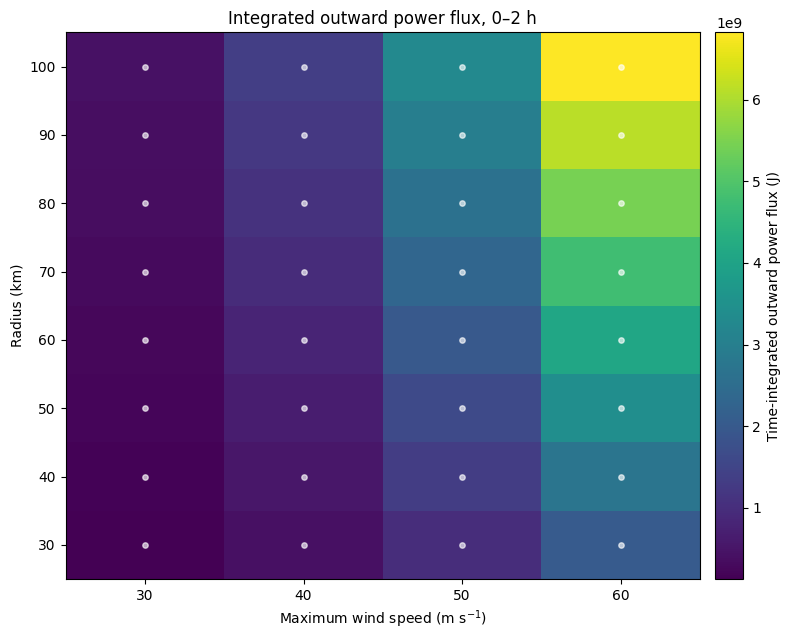

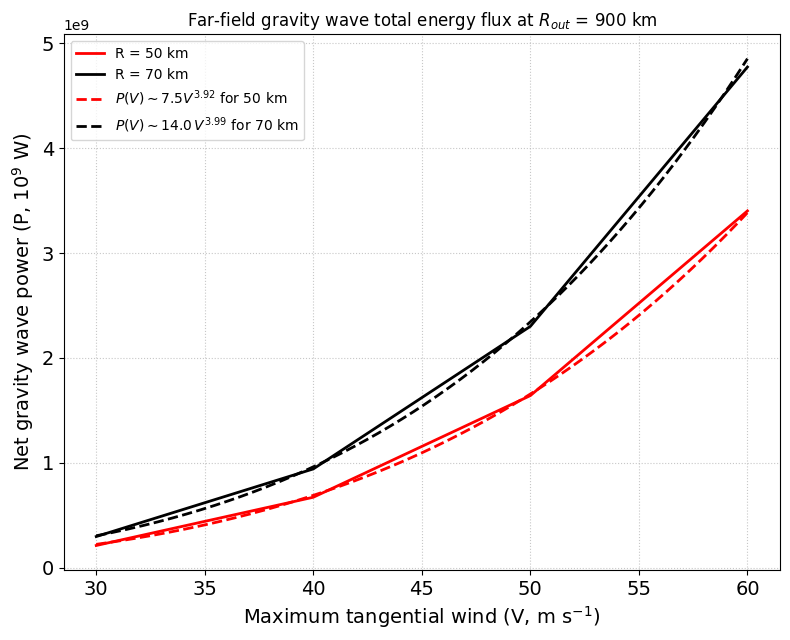

In [3]:
# Integration limit in hours. Change this value as needed.
time_max = 2.0
time_max_s = time_max * 3600.0
if time_max <= 0.0:
    raise ValueError("time_max must be greater than zero.")

# plot full grid 
prefix = "power_flux_timeseries_r900_coupled_0"
files = sorted(output_dir.glob(f"{prefix}_*.csv"))
flux_r900 = get_flux_grid(files,time_max_s,prefix)

# the best fitting in the above graph is ~ 20.3*V^3.92*R^0.882 
wind_values = np.array(sorted({wind for wind, _ in flux_r900}))
radius_values = np.array(sorted({radius for _, radius in flux_r900}))
flux_grid_r900 = np.full((radius_values.size, wind_values.size), np.nan)
wind_index = {value: index for index, value in enumerate(wind_values)}
radius_index = {value: index for index, value in enumerate(radius_values)}

def plot_power_curves(x,M1, M2, R1, R2, title, c1,c2):
    # Vmax range
    V = np.linspace(30, 60, 500)

    # Compute power
    P1 = c1 * V**3.92 * R1**0.882
    P2 = c2 * V**3.99 * R2**0.882

    # Plot
    plt.figure(figsize=(8, 6.5))
    plt.plot(x,M1, 'r', linewidth=2, label='R = 50 km')
    plt.plot(x,M2, 'k', linewidth=2, label='R = 70 km')
    plt.plot(V, P1, 'r--', linewidth=2, label=r'$P(V)\sim 7.5 V^{3.92}$ for 50 km')
    plt.plot(V, P2, 'k--', linewidth=2, label=r'$P(V)\sim 14.0\,V^{3.99}$ for 70 km')

    plt.xlabel("Maximum tangential wind (V, m s$^{-1}$)",fontsize=14)
    plt.ylabel("Net gravity wave power (P, $10^9$ W)",fontsize=14)
    plt.title(title)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()

# plot two profiles at radius 50 km
for (wind, radius), flux in flux_r900.items():
    flux_grid_r900[radius_index[radius], wind_index[wind]] = flux
title = "Far-field gravity wave total energy flux at $R_{out}$ = 900 km"    
plot_power_curves(wind_values,flux_grid_r900[2,:],flux_grid_r900[4,:],50, 70, title, 11.5, 9.2)

## 2. Plot near the RMW at R_out = 360 km,  using R-following perturbation ring fully coupled

Integrated 32 files from 0 to 2 h; grid shape = (8, 4).


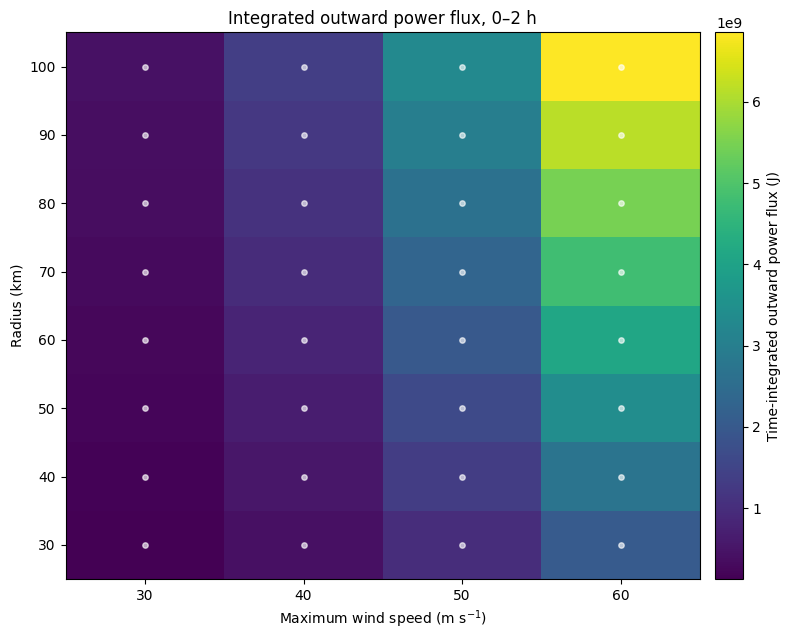

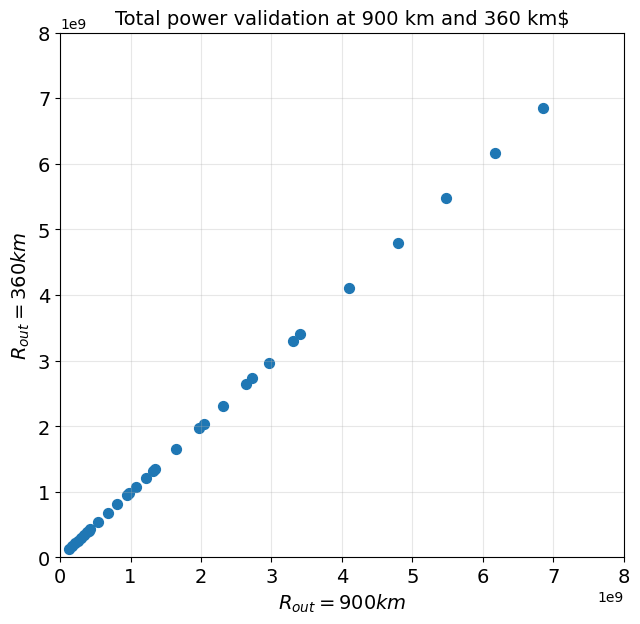

In [4]:
prefix = "power_flux_timeseries_r360_coupled_0"
files = sorted(output_dir.glob(f"{prefix}_*.csv"))
flux_r360 = get_flux_grid(files,time_max_s, prefix)

# plot full grid
flux_grid_r360 = np.full((radius_values.size, wind_values.size), np.nan)

# plot 2 profiles at radius R = 30 and R = 100 km
for (wind, radius), flux in flux_r360.items():
    flux_grid_r360[radius_index[radius], wind_index[wind]] = flux
plt.figure(figsize=(6.5, 6.5))
plt.scatter(flux_grid_r360.ravel(), flux_grid_r360.ravel(), s=50)
plt.xlabel('$R_{out} = 900 km$',fontsize=14)
plt.ylabel('$R_{out} = 360 km$',fontsize=14)
plt.title('Total power validation at 900 km and 360 km$',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 8e9)
plt.ylim(0, 8e9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Plot near the RMW at R_out = 180 km, using R-following perturbation ring fully coupled

Integrated 32 files from 0 to 2 h; grid shape = (8, 4).


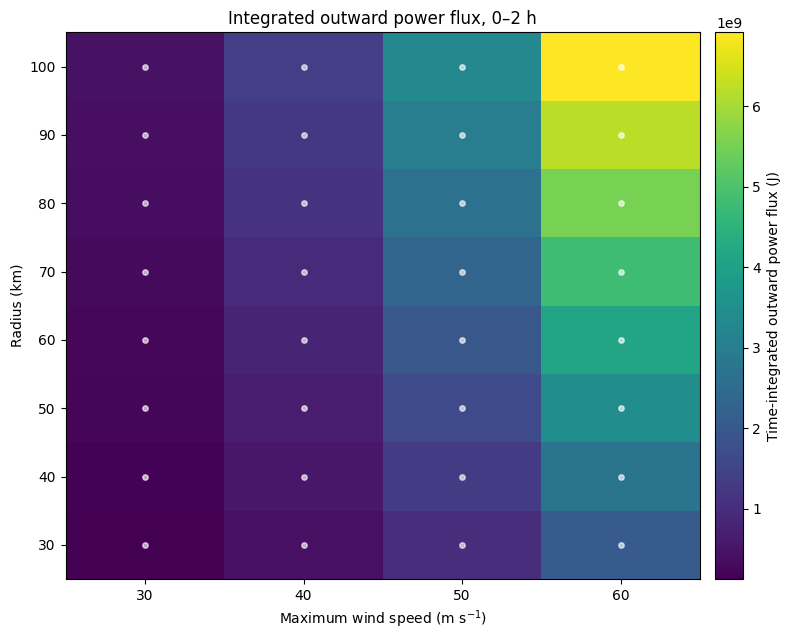

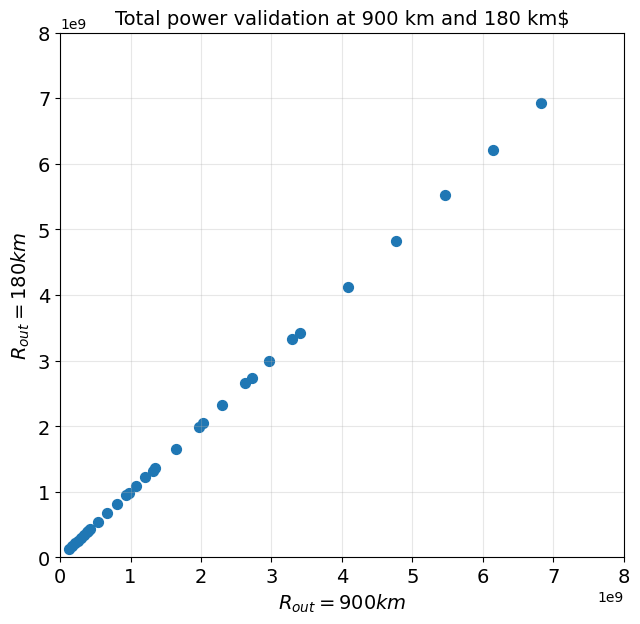

In [6]:
prefix = "power_flux_timeseries_r180_coupled_0"
files = sorted(output_dir.glob(f"{prefix}_*.csv"))
flux_r180 = get_flux_grid(files,time_max_s, prefix)

# plot full grid
flux_grid_r180 = np.full((radius_values.size, wind_values.size), np.nan)

# plot 2 profiles at radius R = 30 and R = 100 km
for (wind, radius), flux in flux_r180.items():
    flux_grid_r180[radius_index[radius], wind_index[wind]] = flux
plt.figure(figsize=(6.5, 6.5))
plt.scatter(flux_grid_r900.ravel(), flux_grid_r180.ravel(), s=50)
plt.xlabel('$R_{out} = 900 km$',fontsize=14)
plt.ylabel('$R_{out} = 180 km$',fontsize=14)
plt.title('Total power validation at 900 km and 180 km$',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 8e9)
plt.ylim(0, 8e9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Plot near the RMW at R_out = 180 km, using R-following perturbation ring uncoupled

Integrated 32 files from 0 to 2 h; grid shape = (8, 4).


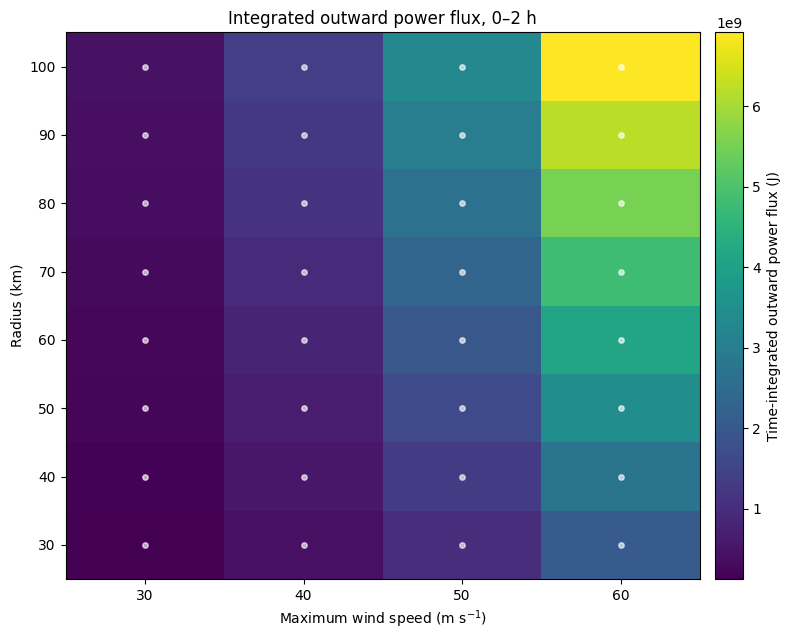

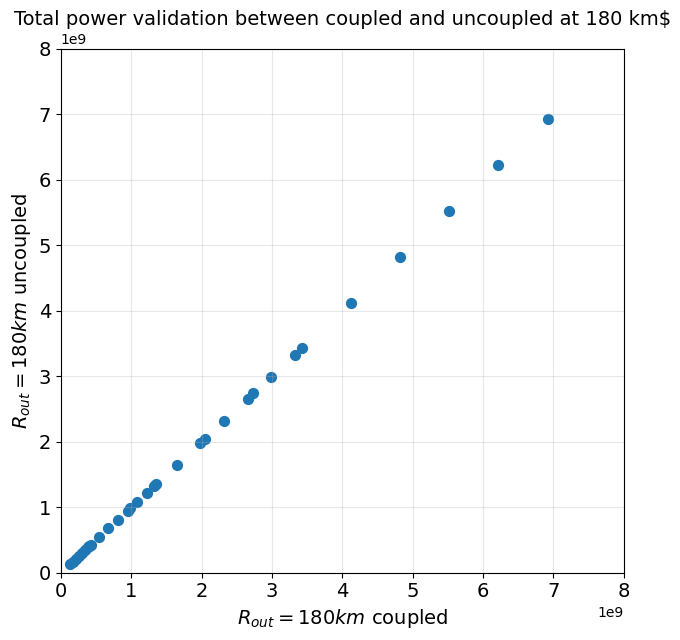

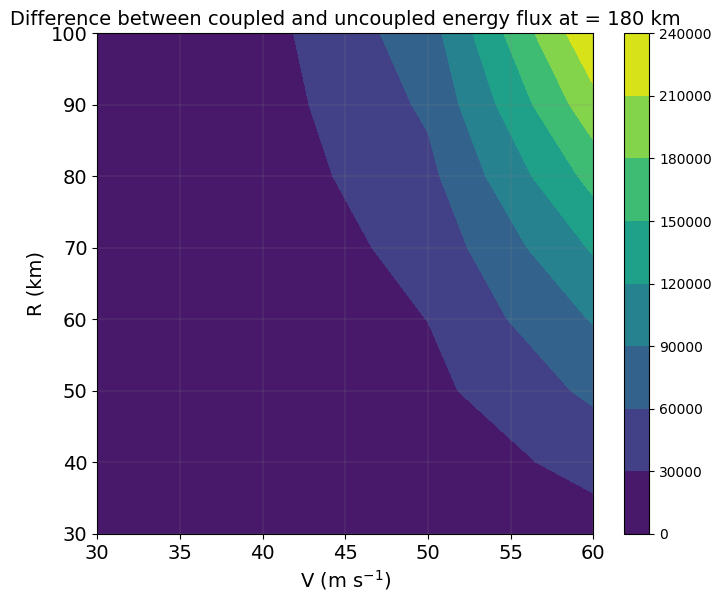

In [8]:
prefix = "power_flux_timeseries_r180_uncoupled_0"
files = sorted(output_dir.glob(f"{prefix}_*.csv"))
flux_u180 = get_flux_grid(files,time_max_s, prefix)

# plot full grid
flux_grid_u180 = np.full((radius_values.size, wind_values.size), np.nan)

# plot 2 profiles at radius R = 30 and R = 100 km
for (wind, radius), flux in flux_u180.items():
    flux_grid_u180[radius_index[radius], wind_index[wind]] = flux
plt.figure(figsize=(6.5, 6.5))
plt.scatter(flux_grid_u180.ravel(), flux_grid_r180.ravel(), s=50)
plt.xlabel('$R_{out} = 180 km$ coupled',fontsize=14)
plt.ylabel('$R_{out} = 180 km$ uncoupled',fontsize=14)
plt.title('Total power validation between coupled and uncoupled at 180 km$',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 8e9)
plt.ylim(0, 8e9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(8, 6.5))
title = "Difference between coupled and uncoupled energy flux at = 180 km"    
X, Y = np.meshgrid(wind_values, radius_values)
plt.contourf(X,Y,flux_grid_r180-flux_grid_u180)
plt.xlabel('V (m s$^{-1}$)',fontsize=14)
plt.ylabel('R (km)',fontsize=14)
plt.title(title,fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(color="gray",linewidth=0.2)
plt.colorbar()

## 5. Plot of pertrubation ring for a fixed RMW = 50 km, V = 50$ms^{-1}$ located at r=30, 70, and 90 km

Integrated 12 files from 0 to 2 h; grid shape = (3, 4).


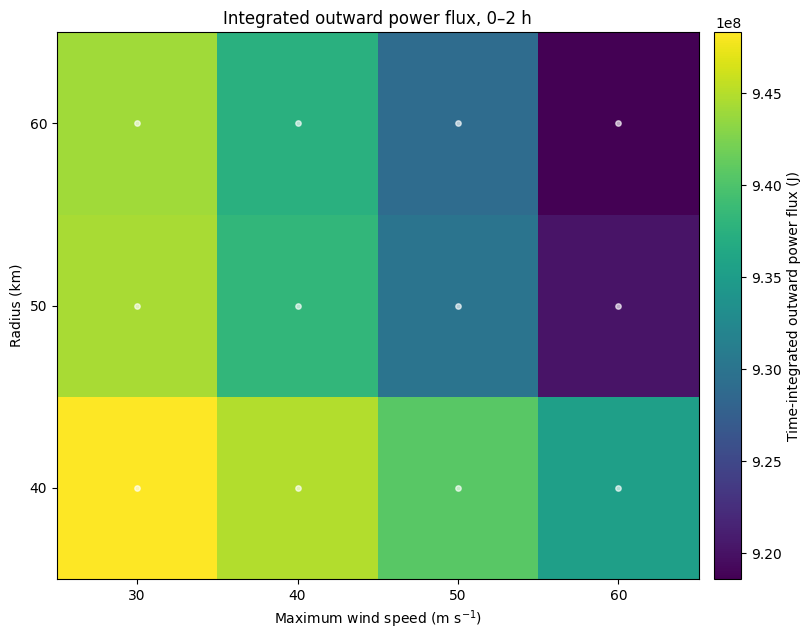

Integrated 12 files from 0 to 2 h; grid shape = (3, 4).


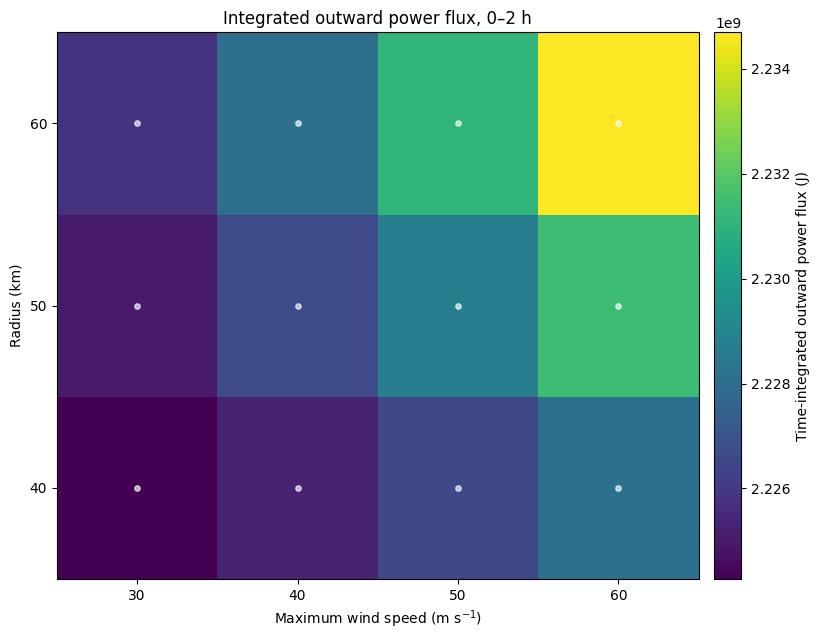

Integrated 12 files from 0 to 2 h; grid shape = (3, 4).


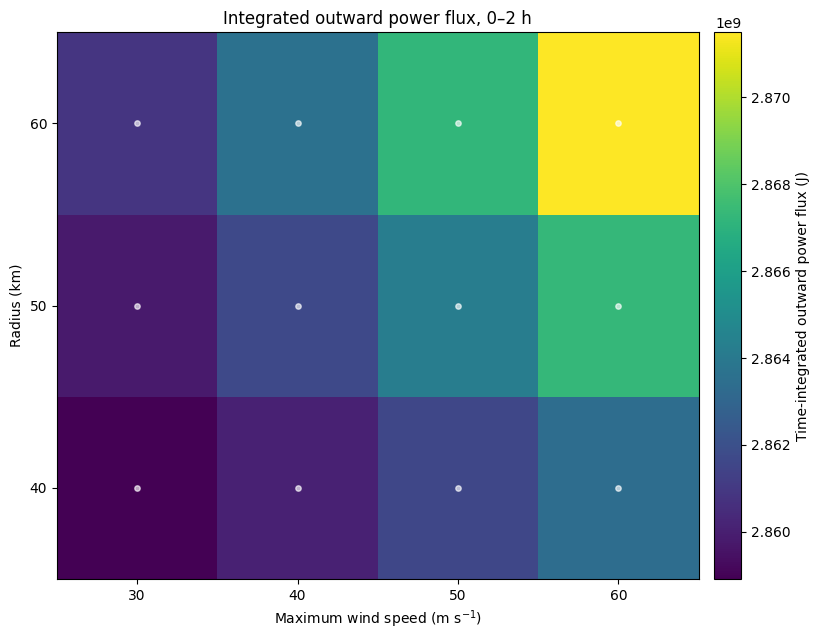

[30. 40. 50. 60.] [40. 50. 60.]


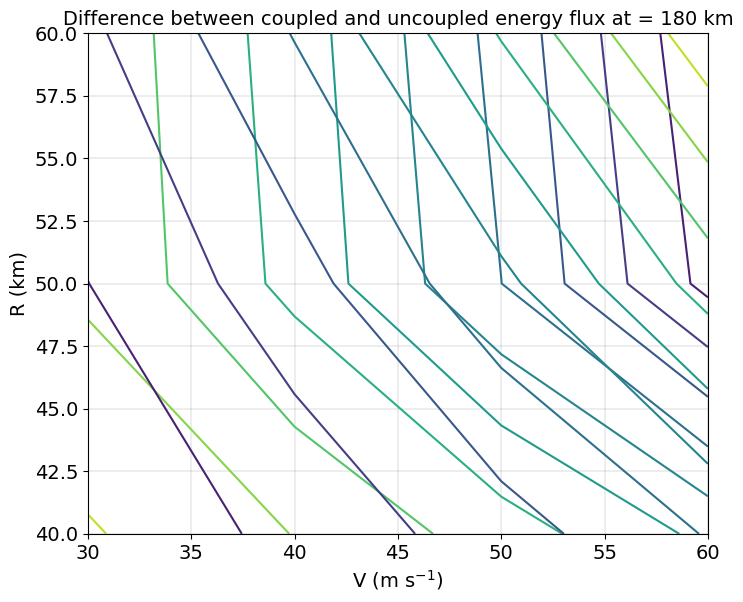

In [35]:
prefix1 = "power_flux_timeseries_r180_inner_30"
files1 = sorted(output_dir.glob(f"{prefix1}_*.csv"))
prefix2 = "power_flux_timeseries_r180_outer1_70"
files2 = sorted(output_dir.glob(f"{prefix2}_*.csv"))
prefix3 = "power_flux_timeseries_r180_outer2_90"
files3 = sorted(output_dir.glob(f"{prefix3}_*.csv"))
flux_r30_R50V50 = get_flux_grid(files1,time_max_s, prefix1)
flux_r70_R50V50 = get_flux_grid(files2,time_max_s, prefix2)
flux_r90_R50V50 = get_flux_grid(files3,time_max_s, prefix3)

# plot full grid
new_wind_values = np.array(sorted({wind for wind, _ in flux_r30_R50V50}))
new_radius_values = np.array(sorted({radius for _, radius in flux_r30_R50V50}))
new_wind_index = {value: index for index, value in enumerate(new_wind_values)}
new_radius_index = {value: index for index, value in enumerate(new_radius_values)}
print(new_wind_values,new_radius_values)

flux_grid_r30_R50V50 = np.full((new_radius_values.size, new_wind_values.size), np.nan)
flux_grid_r70_R50V50 = np.full((new_radius_values.size, new_wind_values.size), np.nan)
flux_grid_r90_R50V50 = np.full((new_radius_values.size, new_wind_values.size), np.nan)

# extract data
for (wind, radius), flux in flux_r30_R50V50.items():
    flux_grid_r30_R50V50[new_radius_index[radius], new_wind_index[wind]] = flux
for (wind, radius), flux in flux_r70_R50V50.items():
    flux_grid_r70_R50V50[new_radius_index[radius], new_wind_index[wind]] = flux
for (wind, radius), flux in flux_r90_R50V50.items():
    flux_grid_r90_R50V50[new_radius_index[radius], new_wind_index[wind]] = flux    

# plot inner/outer contours
plt.figure(figsize=(8, 6.5))
title = "Difference between coupled and uncoupled energy flux at = 180 km"    
X, Y = np.meshgrid(new_wind_values, new_radius_values)
plt.contour(X,Y,flux_grid_r30_R50V50,levels=10)
plt.contour(X,Y,flux_grid_r70_R50V50,levels=10)
plt.xlabel('V (m s$^{-1}$)',fontsize=14)
plt.ylabel('R (km)',fontsize=14)
plt.title(title,fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(color="gray",linewidth=0.2)

/tmp/ipykernel_1394224/283775453.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


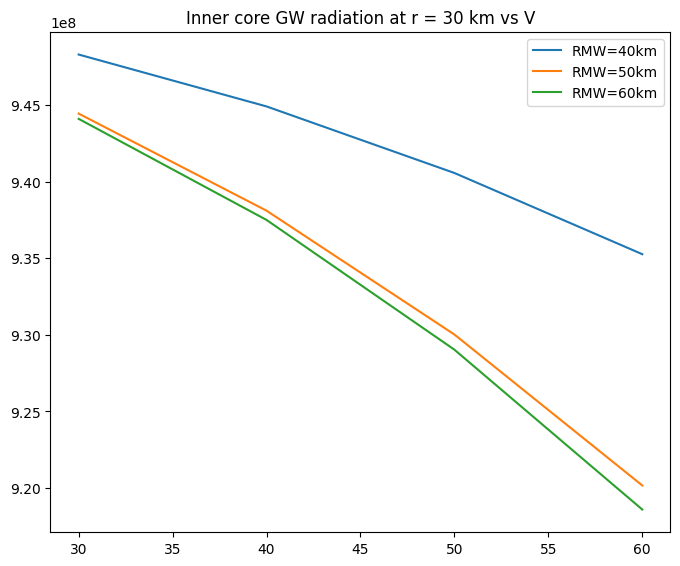

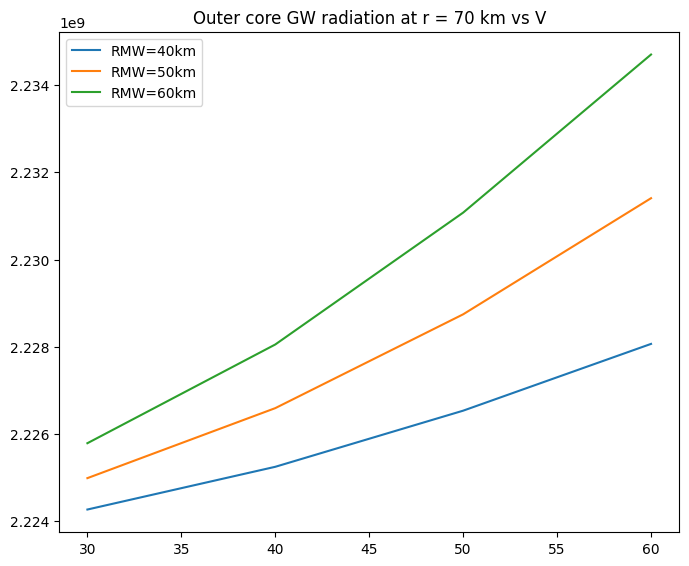

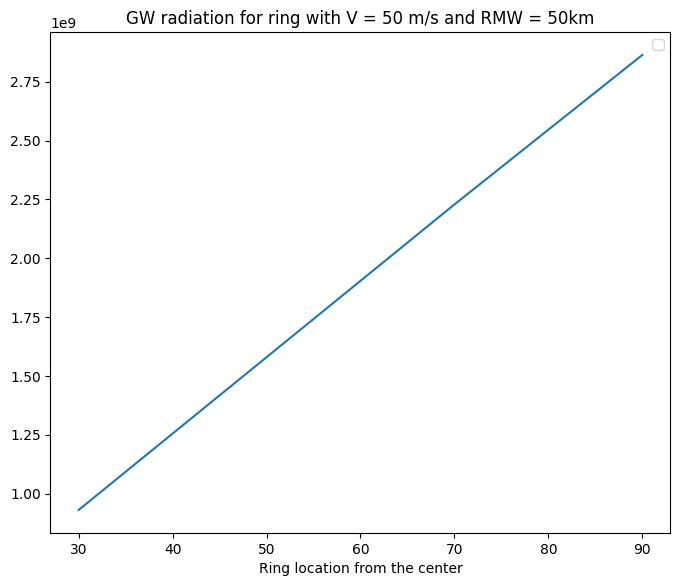

In [46]:
def plot_3power_curves(x, M1, M2, M3, R1, R2, R3, title, c1, c2, c3):
    # Vmax range
    V = np.linspace(30, 60, 500)

    # Compute power
    P1 = c1 * V**3.92 * R1**0.882
    P2 = c2 * V**3.99 * R2**0.882
    P3 = c3 * V**3.99 * R3**0.882

    # Plot
    plt.figure(figsize=(8, 6.5))
    plt.plot(x, M1, 'r', linewidth=2, label='inner core at 30 km')
    plt.plot(x, M2, 'k', linewidth=2, label='outer core at 70 km')
    plt.plot(x, M3, 'g', linewidth=2, label='outer core at 90 km')
    #plt.plot(V, P1, 'r--', linewidth=2, label=r'$P(V)\sim 7.5 V^{3.92}$ for 50 km')
    #plt.plot(V, P2, 'k--', linewidth=2, label=r'$P(V)\sim 14.0\,V^{3.99}$ for 70 km')

    plt.xlabel("Maximum tangential wind (V, m s$^{-1}$)",fontsize=14)
    plt.ylabel("Net gravity wave power (P, $10^9$ W)",fontsize=14)
    plt.title(title)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0,3e9)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()

plt.figure(figsize=(8, 6.5))
plt.plot(new_wind_values,flux_grid_r30_R50V50[0,:],label="RMW=40km")
plt.plot(new_wind_values,flux_grid_r30_R50V50[1,:],label="RMW=50km")
plt.plot(new_wind_values,flux_grid_r30_R50V50[2,:],label="RMW=60km")
plt.title("Inner core GW radiation at r = 30 km vs V")
plt.legend()

plt.figure(figsize=(8, 6.5))
plt.plot(new_wind_values,flux_grid_r70_R50V50[0,:],label="RMW=40km")
plt.plot(new_wind_values,flux_grid_r70_R50V50[1,:],label="RMW=50km")
plt.plot(new_wind_values,flux_grid_r70_R50V50[2,:],label="RMW=60km")
plt.title("Outer core GW radiation at r = 70 km vs V")
plt.legend()

'''
# this plot makes no sense as we cannot compare total flux at different ring radius
r_perb = [30, 70, 90]
p_R50V50 = [flux_grid_r30_R50V50[1,2],flux_grid_r70_R50V50[1,2],flux_grid_r90_R50V50[1,2]]
plt.figure(figsize=(8, 6.5))
plt.plot(r_perb,p_R50V50)
plt.title("GW radiation for ring with V = 50 m/s and RMW = 50km")
plt.xlabel('Ring location from the center')
plt.legend()
#title = "Inner core vs outer core gravity wave radiation"    
#plot_3power_curves(r_perb,p_R40V30,p_R40V40,p_R40V50, 
#                  30, 50, 70, title, 10., 10., 10.)
'''